In [57]:
import os
import cv2
import numpy as np
import mediapipe as mp
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import zipfile


In [58]:
# Google Colab: Extract dataset
zip_path = "/content/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

data_dir = '/content/dataset/train_03'  # Adjust if needed
img_size = 128  # Image size for resizing


In [59]:
# Initialize Mediapipe hand detection
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.7)
mp_draw = mp.solutions.drawing_utils

def process_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(image)
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_draw.draw_landmarks(image, hand_landmarks, mp_hands.HAND_CONNECTIONS)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    image = cv2.resize(image, (img_size, img_size))
    return image

In [60]:
# Load dataset
data = []
labels = []
classes = os.listdir(data_dir)
for label, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        processed_img = process_image(img_path)
        data.append(processed_img)
        labels.append(label)


In [61]:
# Convert to numpy arrays
data = np.array(data).reshape(-1, img_size, img_size, 1) / 255.0
labels = np.array(labels)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

In [62]:
# Define CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

In [63]:
# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Save model
model.save("/content/hand_gesture_model.h5")

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 58s 747ms/step - accuracy: 0.3526 - loss: 1.9421 - val_accuracy: 0.6450 - val_loss: 0.6140
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 81s 733ms/step - accuracy: 0.6329 - loss: 0.8106 - val_accuracy: 0.6600 - val_loss: 0.5498
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 81s 724ms/step - accuracy: 0.6521 - loss: 0.6732 - val_accuracy: 0.6567 - val_loss: 0.5303
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 90s 836ms/step - accuracy: 0.6664 - loss: 0.6012 - val_accuracy: 0.6467 - val_loss: 0.4992
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 75s 748ms/step - accuracy: 0.6671 - loss: 0.5633 - val_accuracy: 0.6600 - val_loss: 0.4928
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 81s 730ms/step - accuracy: 0.6558 - loss: 0.5640 - val_accuracy: 0.6717 - val_loss: 0.4882
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 81s 720ms/step - accuracy: 0.6816 - loss: 0.5276 - val_accuracy: 0.6633 - val_loss: 0.4910
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 55s 729ms/step - accuracy: 0.6450 - loss: 0.5471 - val_accu

In [64]:
# Real-time hand gesture recognition
def recognize_gesture():
    cap = cv2.VideoCapture(0)
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        img = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (img_size, img_size)) / 255.0
        img = np.expand_dims(img, axis=[0, -1])
        pred = model.predict(img)
        label = classes[np.argmax(pred)]
        cv2.putText(frame, label, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.imshow("Hand Gesture Recognition", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()


In [65]:
from tensorflow.keras.models import load_model

model_path = "/content/hand_gesture_model.h5"
model = load_model(model_path)

print("Model loaded successfully!")


Model loaded successfully!


In [66]:
# Function to predict and display an image
def predict_and_display(image_path):
    if not os.path.exists(image_path):
        print(f"Error: Image file not found at {image_path}")
        return

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print("Error: Unable to read the image. Check the file format and path.")
        return

    image_resized = cv2.resize(image, (img_size, img_size)) / 255.0
    image_input = np.expand_dims(image_resized, axis=[0, -1])

    prediction = model.predict(image_input)
    predicted_label = np.argmax(prediction)
    gesture_name = classes[predicted_label]

    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted Gesture: {gesture_name}")
    plt.axis("off")
    plt.show()

    print(f"Predicted Gesture: {gesture_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


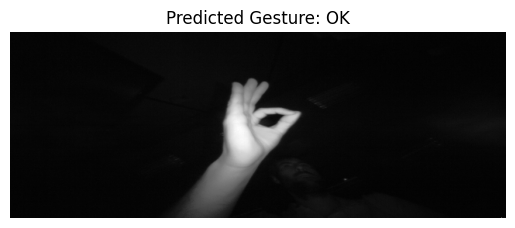

Predicted Gesture: OK


In [67]:
import matplotlib.pyplot as plt
predict_and_display("/content/dataset/train_03/OK/frame_03_07_0002.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


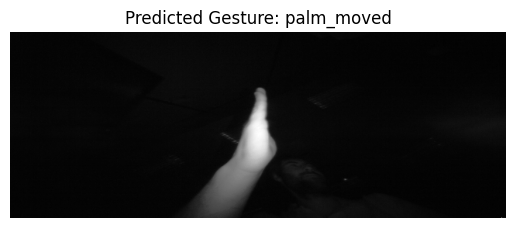

Predicted Gesture: palm_moved


In [68]:
predict_and_display("/content/dataset/train_03/palm_moved/frame_03_08_0002.png")


**🧑‍💻BY:Rishin Aiyappa A G**